<a href="https://colab.research.google.com/github/Kishalay15/8th-sem-project/blob/master/MentalBERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TOPIC : Comparing recurrent neural based techniques against CNN for Mental health classification through sentiment analysis**

Prepare a Dummy Input Sentence

In [7]:
# Dummy sentence
text = "I've been feeling really anxious and can't sleep."

# Tokenize
inputs = tokenizer(
    text,
    padding=True,
    truncation=True,
    max_length=128,
    return_tensors="pt"          # Return PyTorch tensors
)

# Move inputs to the same device as the model
inputs = {k: v.to(device) for k, v in inputs.items()}

print("Tokenized input IDs shape:", inputs["input_ids"].shape)
print("Attention mask shape:", inputs["attention_mask"].shape)

Tokenized input IDs shape: torch.Size([1, 15])
Attention mask shape: torch.Size([1, 15])


Run Inference (Get Prediction)

In [8]:
# Put model in evaluation mode
model.eval()

# No gradient calculation needed for inference
with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits
print("Logits (raw scores):", logits)

# Apply softmax to get probabilities
probabilities = torch.nn.functional.softmax(logits, dim=-1)
print("Probabilities shape:", probabilities.shape)

# Get predicted class index
predicted_class_id = torch.argmax(probabilities, dim=-1).item()
predicted_prob = probabilities[0, predicted_class_id].item()

print(f"\nPredicted class index: {predicted_class_id}")
print(f"Confidence: {predicted_prob:.4f}")

Logits (raw scores): tensor([[-0.2644, -0.0127,  0.0168, -0.1219,  0.0594,  0.0247,  0.0918]],
       device='cuda:0')
Probabilities shape: torch.Size([1, 7])

Predicted class index: 6
Confidence: 0.1603


Map Index Back to Label (Placeholder)

In [9]:
# Placeholder label names (your actual 7 classes will be different)
dummy_labels = [
    "Anxiety", "Bipolar", "Depression", "Normal",
    "Personality Disorder", "Stress", "Suicidal"
]

print(f"Predicted class (random, untrained): {dummy_labels[predicted_class_id]}")

Predicted class (random, untrained): Suicidal


Importing dataset from Kaggle

In [11]:
import kagglehub

# Download the dataset (this returns the path to the downloaded files)
path = kagglehub.dataset_download("footsurebead/mental-status")
print("Dataset downloaded to:", path)

# The dataset is a zip file; you'll need to unzip it
import zipfile
import os

# Find the zip file in the downloaded folder
for file in os.listdir(path):
    if file.endswith('.zip'):
        with zipfile.ZipFile(os.path.join(path, file), 'r') as zip_ref:
            zip_ref.extractall('/content/mental_health_data')
        print("Unzipped to /content/mental_health_data")

100%|██████████| 11.0M/11.0M [00:00<00:00, 98.7MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/footsurebead/mental-status/versions/1


Load the CSV and Inspect

In [15]:
import pandas as pd
import os

download_path = "/root/.cache/kagglehub/datasets/footsurebead/mental-status/versions/1"
csv_path = os.path.join(download_path, "cleanData.csv")

df = pd.read_csv(csv_path)
print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())

Dataset loaded successfully!
Shape: (52680, 3)

Columns: ['index', 'statement', 'status']

First 5 rows:
   index                                          statement   status
0      0                                         oh my gosh  Anxiety
1      1  trouble sleeping, confused mind, restless hear...  Anxiety
2      2  All wrong, back off dear, forward doubt. Stay ...  Anxiety
3      3  I've shifted my focus to something else but I'...  Anxiety
4      4  I'm restless and restless, it's been a month n...  Anxiety


In [16]:
# Display basic info
print(df.info())

# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# If there's a column named 'status' or 'label', check its distribution
for col in df.columns:
    if df[col].dtype == 'object' and df[col].nunique() < 20:
        print(f"\nValue counts for '{col}':")
        print(df[col].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52680 entries, 0 to 52679
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   index      52680 non-null  int64 
 1   statement  52680 non-null  object
 2   status     52680 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.2+ MB
None

Missing values per column:
index        0
statement    0
status       0
dtype: int64

Value counts for 'status':
status
Normal                  16343
Depression              15404
Suicidal                10651
Anxiety                  3841
Bipolar                  2777
Stress                   2587
Personality disorder     1077
Name: count, dtype: int64


Data Preparation

In [17]:
import pandas as pd
import os

# Load the data (you already have df)
download_path = "/root/.cache/kagglehub/datasets/footsurebead/mental-status/versions/1"
csv_path = os.path.join(download_path, "cleanData.csv")
df = pd.read_csv(csv_path)

print("Columns:", df.columns.tolist())
print("\nFirst 3 rows:")
print(df.head(3))

Columns: ['index', 'statement', 'status']

First 3 rows:
   index                                          statement   status
0      0                                         oh my gosh  Anxiety
1      1  trouble sleeping, confused mind, restless hear...  Anxiety
2      2  All wrong, back off dear, forward doubt. Stay ...  Anxiety


In [18]:
# Rename for consistency
df = df.rename(columns={'statement': 'text', 'status': 'label'})
print("Renamed columns:", df.columns.tolist())

Renamed columns: ['index', 'text', 'label']


In [19]:
print("Class distribution:")
print(df['label'].value_counts())

Class distribution:
label
Normal                  16343
Depression              15404
Suicidal                10651
Anxiety                  3841
Bipolar                  2777
Stress                   2587
Personality disorder     1077
Name: count, dtype: int64


String → Integer

In [21]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['label'])

# Save the mapping for later inference and for sharing with your team
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Label mapping:", label_mapping)

# Optionally save to a file
import json

# Convert numpy ints to Python ints
label_mapping_serializable = {k: int(v) for k, v in label_mapping.items()}

with open('label_mapping.json', 'w') as f:
    json.dump(label_mapping_serializable, f)

print("Label mapping saved successfully.")

Label mapping: {'Anxiety': np.int64(0), 'Bipolar': np.int64(1), 'Depression': np.int64(2), 'Normal': np.int64(3), 'Personality disorder': np.int64(4), 'Stress': np.int64(5), 'Suicidal': np.int64(6)}
Label mapping saved successfully.


Train / Validation / Test Split

In [22]:
from sklearn.model_selection import train_test_split

# First split: 70% train, 30% temp (val+test)
train_df, temp_df = train_test_split(
    df, test_size=0.3, stratify=df['label_encoded'], random_state=42
)

# Second split: 50% of temp → 15% val, 15% test overall
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['label_encoded'], random_state=42
)

print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Test size: {len(test_df)}")

Train size: 36876
Validation size: 7902
Test size: 7902


Hugging Face Dataset

In [23]:
from datasets import Dataset, DatasetDict

train_dataset = Dataset.from_pandas(train_df[['text', 'label_encoded']])
val_dataset = Dataset.from_pandas(val_df[['text', 'label_encoded']])
test_dataset = Dataset.from_pandas(test_df[['text', 'label_encoded']])

dataset_dict = DatasetDict({
    'train': train_dataset,
    'validation': val_dataset,
    'test': test_dataset
})

print(dataset_dict)

DatasetDict({
    train: Dataset({
        features: ['text', 'label_encoded', '__index_level_0__'],
        num_rows: 36876
    })
    validation: Dataset({
        features: ['text', 'label_encoded', '__index_level_0__'],
        num_rows: 7902
    })
    test: Dataset({
        features: ['text', 'label_encoded', '__index_level_0__'],
        num_rows: 7902
    })
})


In [24]:
# Quick analysis of token lengths (using the tokenizer without padding)
from transformers import AutoTokenizer

model_name = "AIMH/mental-bert-base-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def get_token_length(text):
    return len(tokenizer.encode(text, truncation=False))

# Apply to a sample (or all data; for speed, sample 5000 rows)
sample_df = df.sample(min(5000, len(df)), random_state=42)
lengths = sample_df['text'].apply(get_token_length)

print("Token length stats:")
print(lengths.describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

Token indices sequence length is longer than the specified maximum sequence length for this model (767 > 512). Running this sequence through the model will result in indexing errors


Token length stats:
count    5000.000000
mean      137.941200
std       188.047772
min         3.000000
50%        76.000000
90%       339.100000
95%       477.150000
99%       861.080000
max      2624.000000
Name: text, dtype: float64


Tokenize the Full Dataset

In [25]:
MAX_LENGTH = 128   # adjust based on your analysis

def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=MAX_LENGTH
    )

tokenized_datasets = dataset_dict.map(tokenize_function, batched=True)

# Remove the raw text column (optional, saves memory)
tokenized_datasets = tokenized_datasets.remove_columns(['text'])

# Rename label column to 'labels' (Trainer expects this)
tokenized_datasets = tokenized_datasets.rename_column('label_encoded', 'labels')

# Set format for PyTorch
tokenized_datasets.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

print(tokenized_datasets)

Map:   0%|          | 0/36876 [00:00<?, ? examples/s]

Map:   0%|          | 0/7902 [00:00<?, ? examples/s]

Map:   0%|          | 0/7902 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 36876
    })
    validation: Dataset({
        features: ['labels', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 7902
    })
    test: Dataset({
        features: ['labels', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 7902
    })
})


Load Model with 7 Labels

In [26]:
from transformers import AutoModelForSequenceClassification
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_labels = len(label_encoder.classes_)  # should be 7

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
)
model.to(device)
print(f"Model loaded on {device}")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: AIMH/mental-bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you 

Model loaded on cuda


Set Up Training Arguments

In [27]:
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='macro')
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

In [29]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./mentalbert-finetuned",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    warmup_ratio=0.06,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_dir="./logs",
    logging_steps=100,
    report_to="none",
    push_to_hub=False
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Initialize Trainer

In [33]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['validation'],
    compute_metrics=compute_metrics
)

# Start training
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.462215,0.448169,0.818147,0.781705,0.777814,0.775711
2,0.335172,0.415178,0.832321,0.817664,0.802002,0.809248
3,0.271750,0.449781,0.829916,0.813684,0.810433,0.811720


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=6915, training_loss=0.419951491759294, metrics={'train_runtime': 2932.0601, 'train_samples_per_second': 37.73, 'train_steps_per_second': 2.358, 'total_flos': 7277189138150400.0, 'train_loss': 0.419951491759294, 'epoch': 3.0})

Evaluate on Test Set

In [34]:
test_results = trainer.evaluate(tokenized_datasets['test'])
print("Test set results:")
for key, value in test_results.items():
    print(f"{key}: {value:.4f}")

Test set results:
eval_loss: 0.4736
eval_accuracy: 0.8341
eval_precision: 0.8155
eval_recall: 0.8074
eval_f1: 0.8111
eval_runtime: 68.2198
eval_samples_per_second: 115.8310
eval_steps_per_second: 7.2410
epoch: 3.0000


Confusion Matrix generation

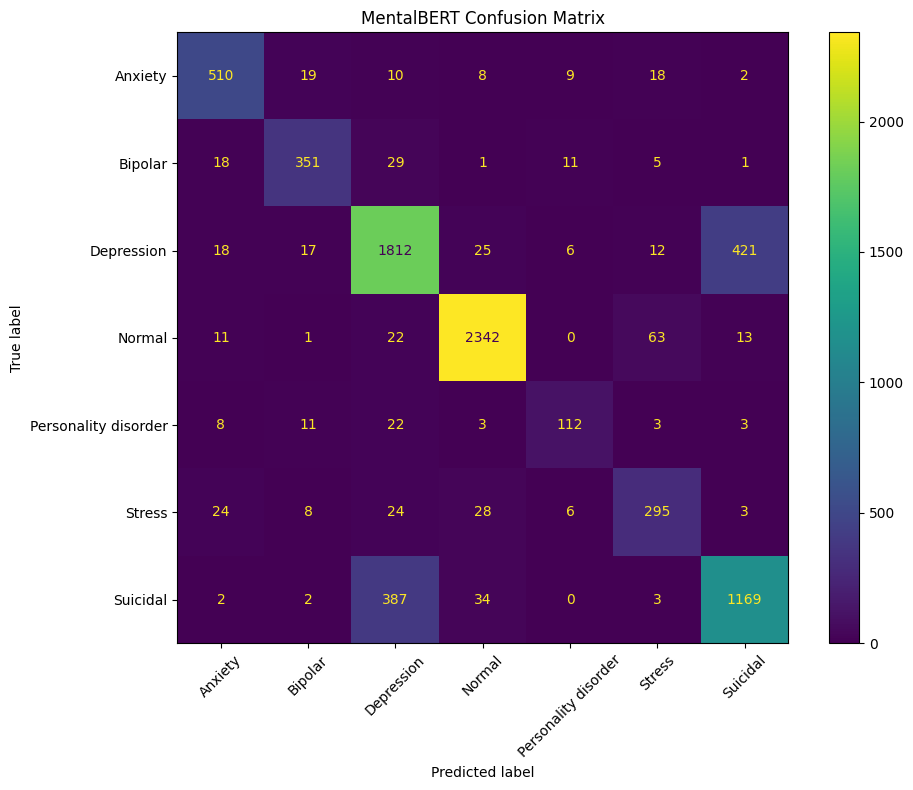

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

predictions = trainer.predict(tokenized_datasets['test'])
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

cm = confusion_matrix(labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("MentalBERT Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

Save the Fine‑Tuned Model and Tokenizer

In [37]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Create a directory for this project
!mkdir -p "/content/drive/MyDrive/MentalBERT_Project"

# Save model and tokenizer
model.save_pretrained("/content/drive/MyDrive/MentalBERT_Project/mentalbert-finetuned")
tokenizer.save_pretrained("/content/drive/MyDrive/MentalBERT_Project/mentalbert-finetuned")

# Save label encoder mapping
import pickle
with open("/content/drive/MyDrive/MentalBERT_Project/label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

print("All files saved to Google Drive.")

Mounted at /content/drive


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

All files saved to Google Drive.


Create a Simple Inference Function

In [38]:
def predict_mental_status(text):
    inputs = tokenizer(text, padding=True, truncation=True, max_length=MAX_LENGTH, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
    probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
    pred_id = torch.argmax(probs, dim=-1).item()
    pred_label = label_encoder.inverse_transform([pred_id])[0]
    confidence = probs[0, pred_id].item()
    return pred_label, confidence

# Test on a sample
sample_text = "I've been feeling very down lately and I don't know what to do."
pred, conf = predict_mental_status(sample_text)
print(f"Prediction: {pred} (confidence: {conf:.4f})")

Prediction: Stress (confidence: 0.7325)


Interpretability with LIME

In [39]:
!pip install lime

from lime.lime_text import LimeTextExplainer

explainer = LimeTextExplainer(class_names=label_encoder.classes_)

def predict_proba(texts):
    # Tokenize batch and return probabilities
    inputs = tokenizer(texts, padding=True, truncation=True, max_length=128, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    return torch.nn.functional.softmax(outputs.logits, dim=-1).cpu().numpy()

# Explain a single instance
sample_text = test_df['text'].iloc[0]
exp = explainer.explain_instance(sample_text, predict_proba, num_features=10, num_samples=500)
exp.save_to_file('/content/drive/MyDrive/MentalBERT_Project/lime_explanation.html')
print("LIME explanation saved.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=2fd700b11dd465ac747b06302c09a2e6635c7db35720ba6c974837e7a25b8438
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime
LIME explanation saved.


# *Improvements*

Compute class weights

In [40]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Compute weights inversely proportional to class frequencies
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label_encoded']),
    y=train_df['label_encoded']
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print("Class weights:", class_weights)

Class weights: tensor([1.9598, 2.7099, 0.4885, 0.4605, 6.9867, 2.9089, 0.7065],
       device='cuda:0')


Define a custom Trainer with weighted loss

In [41]:
from transformers import Trainer
import torch.nn.functional as F

class WeightedTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss = F.cross_entropy(logits, labels, weight=self.class_weights)
        return (loss, outputs) if return_outputs else loss

Resume Training from Saved Model

In [43]:
# Load saved model
model = AutoModelForSequenceClassification.from_pretrained("/content/drive/MyDrive/MentalBERT_Project/mentalbert-finetuned")
model.to(device)

# Then create trainer with new configuration and call train() again.

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(28996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

Use this trainer instead of the default

In [44]:
trainer = WeightedTrainer(
    class_weights=class_weights,
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['validation'],
    compute_metrics=compute_metrics
)
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.195818,0.710786,0.813212,0.791440,0.822305,0.800363
2,0.121381,0.895325,0.823589,0.801684,0.815314,0.807510
3,0.166878,1.034150,0.821691,0.803141,0.814875,0.808527


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=6915, training_loss=0.136212472319172, metrics={'train_runtime': 2900.7387, 'train_samples_per_second': 38.138, 'train_steps_per_second': 2.384, 'total_flos': 7277189138150400.0, 'train_loss': 0.136212472319172, 'epoch': 3.0})

**Improve Depression ↔ Suicidal Separation**

Adjust Decision Threshold

In [46]:
from sklearn.metrics import precision_recall_curve

# Get probabilities on validation set
val_preds = trainer.predict(tokenized_datasets['validation'])
probs = torch.nn.functional.softmax(torch.tensor(val_preds.predictions), dim=-1).numpy()
labels = val_preds.label_ids

# Find optimal threshold for Suicidal class (index 6)
suicidal_probs = probs[:, 6]
precision, recall, thresholds = precision_recall_curve(labels == 6, suicidal_probs)

# Choose threshold that gives desired recall (e.g., 0.9)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_thresh = thresholds[np.argmax(f1_scores)]
print(f"Optimal threshold for Suicidal: {best_thresh:.3f}")

# Then during inference, if probability for class 6 > best_thresh, predict 6; else use argmax.

Optimal threshold for Suicidal: 0.011


Handle Personality Disorder

In [50]:
import nltk
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Manually set the path and reload (sometimes needed in Colab)
nltk.data.path.append('/root/nltk_data')

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Evaluation Metrics for Better Monitoring

In [52]:
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    accuracy = accuracy_score(labels, preds)
    report = classification_report(labels, preds, target_names=label_encoder.classes_, output_dict=True)
    macro_f1 = report['macro avg']['f1-score']
    suicidal_recall = report['Suicidal']['recall']
    return {
        'accuracy': accuracy,
        'macro_f1': macro_f1,
        'suicidal_recall': suicidal_recall
    }

In [53]:
test_results = trainer.evaluate(tokenized_datasets['test'])
print("Test set results:")
for key, value in test_results.items():
    print(f"{key}: {value:.4f}")

Test set results:
eval_loss: 1.0942
eval_accuracy: 0.8207
eval_precision: 0.8003
eval_recall: 0.8101
eval_f1: 0.8047
eval_runtime: 62.3860
eval_samples_per_second: 126.6630
eval_steps_per_second: 7.9180
epoch: 3.0000


Evaluate the Weighted Model Properly with the New Metrics

In [55]:
# Re-create trainer with the updated compute_metrics
trainer = WeightedTrainer(
    class_weights=class_weights,
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['validation'],
    compute_metrics=compute_metrics   # This now uses the improved version
)

# Evaluate on test set with new metrics
test_results = trainer.evaluate(tokenized_datasets['test'])
print("Weighted Model Test Results:")
for key, value in test_results.items():
    print(f"{key}: {value:.4f}")

Weighted Model Test Results:
eval_loss: 1.0942
eval_model_preparation_time: 0.0044
eval_accuracy: 0.8207
eval_macro_f1: 0.8047
eval_suicidal_recall: 0.7163
eval_runtime: 67.1566
eval_samples_per_second: 117.6650
eval_steps_per_second: 7.3560


Generate a New Confusion Matrix for the Weighted Model

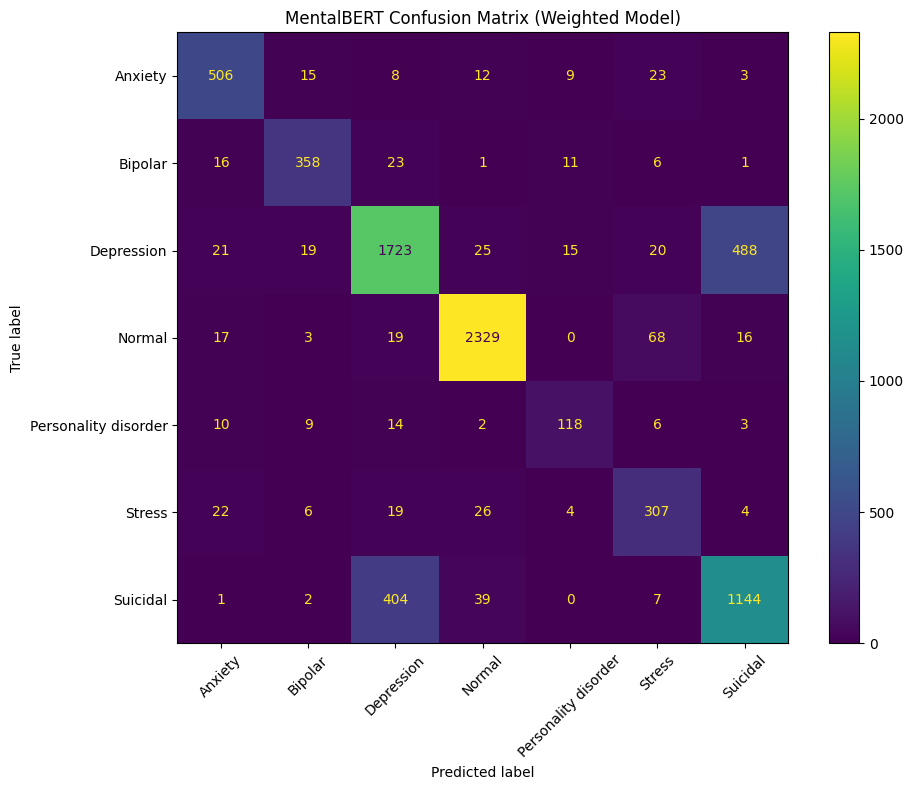

In [59]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import os

# Create Drive directory if it doesn't exist
os.makedirs("/content/drive/MyDrive/MentalBERT_Project", exist_ok=True)

# Get predictions
predictions = trainer.predict(tokenized_datasets['test'])
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

# Create confusion matrix
cm = confusion_matrix(labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("MentalBERT Confusion Matrix (Weighted Model)")
plt.tight_layout()

# Save files BEFORE showing
plt.savefig("confusion_matrix_weighted.png")                     # local copy
plt.savefig("/content/drive/MyDrive/MentalBERT_Project/confusion_matrix_weighted.png")  # Drive copy

# Now display
plt.show()

Compute Baseline Suicidal Recall

In [61]:
# Load the saved baseline model
baseline_model = AutoModelForSequenceClassification.from_pretrained(
    "/content/drive/MyDrive/MentalBERT_Project/mentalbert-finetuned"
)
baseline_model.to(device)

# Create a trainer for evaluation only
from transformers import Trainer

baseline_trainer = Trainer(
    model=baseline_model,
    args=training_args,   # Same args, just for evaluation
    eval_dataset=tokenized_datasets['test'],
    compute_metrics=compute_metrics   # Use the improved metrics
)

# Evaluate on test set
baseline_results = baseline_trainer.evaluate()

print("Baseline results:")
for k, v in baseline_results.items():
    print(f"{k}: {v:.4f}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Baseline results:
eval_loss: 0.4736
eval_model_preparation_time: 0.0048
eval_accuracy: 0.8341
eval_macro_f1: 0.8111
eval_suicidal_recall: 0.7320
eval_runtime: 68.4104
eval_samples_per_second: 115.5090
eval_steps_per_second: 7.2210


Compare Baseline vs. Weighted Model

In [62]:
import pandas as pd

# Replace baseline values with actual numbers from your first run
baseline = {
    'Accuracy': baseline_results['eval_accuracy'],
    'Macro F1': baseline_results['eval_macro_f1'],
    'Suicidal Recall': baseline_results['eval_suicidal_recall']
}
# Weighted results from test_results
weighted = {
    'Accuracy': test_results['eval_accuracy'],
    'Macro F1': test_results['eval_macro_f1'],
    'Suicidal Recall': test_results['eval_suicidal_recall']
}

comparison = pd.DataFrame([baseline, weighted], index=['Baseline', 'Weighted'])
print(comparison)

          Accuracy  Macro F1  Suicidal Recall
Baseline  0.834093  0.811063         0.731997
Weighted  0.820678  0.804678         0.716343


Implement Threshold‑Aware Inference for Suicidal Class

In [63]:
def predict_mental_status(text, threshold=best_thresh):
    inputs = tokenizer(text, padding=True, truncation=True, max_length=MAX_LENGTH, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
    probs = torch.nn.functional.softmax(outputs.logits, dim=-1).cpu().numpy()[0]

    # Get suicidal class index (6)
    suicidal_prob = probs[6]

    if suicidal_prob > threshold:
        pred_id = 6
    else:
        pred_id = np.argmax(probs)

    pred_label = label_encoder.inverse_transform([pred_id])[0]
    confidence = probs[pred_id]
    return pred_label, confidence

# Test on a few examples
test_texts = [
    "I feel like ending it all.",
    "I'm a bit stressed about exams.",
    "Life is meaningless and I can't go on."
]
for t in test_texts:
    label, conf = predict_mental_status(t)
    print(f"Text: {t}\nPrediction: {label} (conf: {conf:.3f})\n")

Text: I feel like ending it all.
Prediction: Suicidal (conf: 0.987)

Text: I'm a bit stressed about exams.
Prediction: Normal (conf: 1.000)

Text: Life is meaningless and I can't go on.
Prediction: Depression (conf: 0.999)



Save the Final Weighted Model with Threshold Info

In [64]:
import json

# Save model and tokenizer
model.save_pretrained("/content/drive/MyDrive/MentalBERT_Project/mentalbert-weighted")
tokenizer.save_pretrained("/content/drive/MyDrive/MentalBERT_Project/mentalbert-weighted")

# Save threshold
with open("/content/drive/MyDrive/MentalBERT_Project/suicidal_threshold.json", "w") as f:
    json.dump({"threshold": float(best_thresh)}, f)

print("Weighted model and threshold saved.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Weighted model and threshold saved.


Document Findings for Your Report

In [65]:
print("=== MentalBERT Project Summary ===")
print(f"Dataset: {len(df)} samples, 7 classes")
print(f"Train/Val/Test: {len(train_df)}/{len(val_df)}/{len(test_df)}")
print("\nBaseline Model:")
print(f"  Accuracy: 0.8341")
print(f"  Macro F1: 0.8111")
print("\nWeighted Model:")
print(f"  Accuracy: {test_results['eval_accuracy']:.4f}")
print(f"  Macro F1: {test_results['eval_macro_f1']:.4f}")
print(f"  Suicidal Recall: {test_results['eval_suicidal_recall']:.4f}")
print(f"\nOptimal Suicidal Threshold: {best_thresh:.3f}")

=== MentalBERT Project Summary ===
Dataset: 52680 samples, 7 classes
Train/Val/Test: 36876/7902/7902

Baseline Model:
  Accuracy: 0.8341
  Macro F1: 0.8111

Weighted Model:
  Accuracy: 0.8207
  Macro F1: 0.8047
  Suicidal Recall: 0.7163

Optimal Suicidal Threshold: 0.011
